# NB08 — SoilHive Data Consolidation
Consolidate WoSIS point data and SoilGrids raster extractions across all countries
into a single station-level merged dataset.

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

DATA_DIR   = "/home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data"
OUTPUT_DIR = "/home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/reports"
SG_PARQUET = os.path.join(DATA_DIR, "soilgrids_surface_all_countries.parquet")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Imports OK")
print(f"SoilGrids parquet : {SG_PARQUET}")
print(f"Exists            : {os.path.exists(SG_PARQUET)}")


Imports OK
SoilGrids parquet : /home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/soilgrids_surface_all_countries.parquet
Exists            : True


In [2]:
def get_country_folders(data_dir):
    return sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
        and not d.startswith(("Y", "Z", "_"))
    ])


def load_wosis(country_folder):
    """Load output_data_points.csv for a country."""
    path = os.path.join(country_folder, "output_data_points.csv")
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df["country"] = os.path.basename(country_folder)
    return df

print("Helper functions defined.")


def get_available_sg_properties(sg_folder, surface="0-5cm"):
    """Return list of SG property names that have a surface TIF."""
    tifs = glob.glob(os.path.join(sg_folder, f"*_{surface}_mean.tif"))
    return sorted(set(
        os.path.basename(t).replace(f"_{surface}_mean.tif", "")
        for t in tifs
    ))

print("Helper functions defined.")


Helper functions defined.
Helper functions defined.


## Phase 1 — Inventory all countries

In [3]:
print("=" * 80)
print("PHASE 1 - INVENTORY")
print("=" * 80)

countries = get_country_folders(DATA_DIR)
inventory = []

for c in countries:
    base = os.path.join(DATA_DIR, c)
    sg_folder = os.path.join(base, "SoilGrids_250m")

    df = load_wosis(base)
    n_rows = len(df) if df is not None else 0
    n_stations = df.groupby(["lat","lon"]).ngroups if df is not None else 0
    n_wosis_props = df["property"].nunique() if df is not None else 0
    wosis_props = sorted(df["property"].unique().tolist()) if df is not None else []

    has_sg = os.path.isdir(sg_folder)
    tifs = glob.glob(os.path.join(sg_folder, "*.tif")) if has_sg else []
    sg_props = get_available_sg_properties(sg_folder) if has_sg else []

    inventory.append({
        "country": c,
        "n_rows": n_rows,
        "n_stations": n_stations,
        "n_wosis_props": n_wosis_props,
        "wosis_props": wosis_props,
        "has_sg": has_sg,
        "n_sg_tifs": len(tifs),
        "n_sg_props": len(sg_props),
        "sg_props": sg_props,
    })
    print(f"  {c:45s} | {n_stations:5d} stations | {n_wosis_props:2d} WoSIS props | {len(sg_props):2d} SG props")

inv_df = pd.DataFrame(inventory)
print(f"\nTOTAL: {len(countries)} countries, {inv_df['n_stations'].sum():,} stations, {inv_df['n_rows'].sum():,} rows")
print(f"With SoilGrids: {inv_df['has_sg'].sum()} countries")

PHASE 1 - INVENTORY
  Argentina                                     |   285 stations | 18 WoSIS props |  3 SG props
  Argentina_Patagonia                           |   285 stations | 18 WoSIS props |  2 SG props
  Austria                                       |   129 stations | 13 WoSIS props | 13 SG props
  Bangladesh                                    |   200 stations | 11 WoSIS props | 13 SG props


  Belarus                                       |    92 stations | 11 WoSIS props | 13 SG props


  Belgium                                       |  6969 stations | 18 WoSIS props | 13 SG props
  Bolivia,_Plurinational_State_of               |    82 stations | 11 WoSIS props |  2 SG props
  Bonaire,_Sint_Eustatius_and_Saba              |  1354 stations | 19 WoSIS props | 13 SG props
  Bosnia_and_Herzegovina                        |    31 stations |  4 WoSIS props | 13 SG props
  Brazil                                        |     2 stations |  9 WoSIS props |  4 SG props
  Bulgaria                                      |   137 stations | 20 WoSIS props | 13 SG props
  Canary_Islands                                |   846 stations | 20 WoSIS props | 13 SG props
  Colombia                                      |   174 stations | 20 WoSIS props | 13 SG props
  Costa_Rica                                    |   557 stations | 20 WoSIS props | 13 SG props
  Cyprus                                        |     9 stations |  4 WoSIS props | 13 SG props
  Czechia                               

  French_Guiana                                 |  3127 stations | 20 WoSIS props | 13 SG props
  Honduras                                      |    22 stations | 13 WoSIS props | 13 SG props
  Hungary                                       |  1408 stations | 18 WoSIS props | 13 SG props
  Iceland                                       |     8 stations | 10 WoSIS props | 13 SG props
  India                                         |   172 stations | 19 WoSIS props |  4 SG props
  Indonesia                                     |   172 stations | 20 WoSIS props |  0 SG props
  Ireland                                       |   166 stations | 17 WoSIS props | 13 SG props
  Italy                                         |   516 stations | 19 WoSIS props | 13 SG props
  Japan                                         |   130 stations | 19 WoSIS props | 13 SG props
  Korea,_Republic_of                            |    23 stations | 12 WoSIS props | 13 SG props
  Latvia                                

  Mexico                                        |  7494 stations | 14 WoSIS props |  3 SG props
  Monaco                                        |     0 stations |  0 WoSIS props | 13 SG props
  Nepal                                         |   140 stations | 13 WoSIS props | 13 SG props
  North_Macedonia                               |    27 stations |  5 WoSIS props | 13 SG props
  Norway                                        |   379 stations | 17 WoSIS props | 13 SG props
  Pakistan                                      |    47 stations | 18 WoSIS props |  0 SG props
  Peru                                          |   181 stations | 18 WoSIS props | 13 SG props
  Philippines                                   |    68 stations | 19 WoSIS props | 13 SG props
  Poland                                        |   680 stations | 20 WoSIS props | 13 SG props
  Portugal                                      |   433 stations | 12 WoSIS props | 13 SG props
  Romania                               

  Switzerland                                   | 10436 stations | 12 WoSIS props | 13 SG props
  Thailand                                      |     1 stations |  8 WoSIS props | 13 SG props
  Thailand_North                                |   378 stations | 19 WoSIS props | 13 SG props
  Ukraine                                       |   461 stations | 14 WoSIS props | 13 SG props
  United_Kingdom                                |  1462 stations | 15 WoSIS props | 13 SG props
  Unknown_SG_only                               |     0 stations |  0 WoSIS props | 11 SG props
  Uruguay                                       |   129 stations | 19 WoSIS props | 13 SG props
  Vatican_City                                  |     0 stations |  0 WoSIS props |  0 SG props
  Viet_Nam                                      |    53 stations |  7 WoSIS props | 13 SG props

TOTAL: 62 countries, 42,782 stations, 909,214 rows
With SoilGrids: 59 countries


## Phase 2 — Consolidate WoSIS Data

In [4]:
print("=" * 80)
print("PHASE 2 - CONSOLIDATE WoSIS DATA")
print("=" * 80)

all_wosis = []
issues = []

for c in countries:
    base = os.path.join(DATA_DIR, c)
    df = load_wosis(base)
    if df is None:
        issues.append({"country": c, "issue": "missing output_data_points.csv"})
        continue

    # Check for stations with no data (all values NaN)
    station_completeness = df.groupby(["lat","lon"])["value"].apply(lambda x: x.notna().sum())
    empty_stations = (station_completeness == 0).sum()
    if empty_stations > 0:
        issues.append({"country": c, "issue": f"{empty_stations} stations with 0 non-null values"})

    all_wosis.append(df)

wosis_df = pd.concat(all_wosis, ignore_index=True)
print(f"Combined WoSIS dataset: {len(wosis_df):,} rows")
print(f"Countries: {wosis_df['country'].nunique()}")
print(f"Total unique stations: {wosis_df.groupby(['lat','lon','country']).ngroups:,}")
print(f"Properties: {sorted(wosis_df['property'].unique().tolist())}")
print(f"\nIssues found: {len(issues)}")
for iss in issues:
    print(f"  {iss['country']}: {iss['issue']}")

PHASE 2 - CONSOLIDATE WoSIS DATA


Combined WoSIS dataset: 909,214 rows
Countries: 55
Total unique stations: 42,782
Properties: ['BD', 'CEC', 'CF', 'Ca', 'CaCO3', 'EC', 'K', 'Mg', 'N', 'Na', 'P', 'TC', 'WR_gravimetric', 'WR_volumetric', 'clay', 'nematode', 'occ', 'pH', 'sand', 'silt']

Issues found: 7
  Djibouti: missing output_data_points.csv
  Liechtenstein: missing output_data_points.csv
  Malta: missing output_data_points.csv
  Monaco: missing output_data_points.csv
  San_Marino: missing output_data_points.csv
  Unknown_SG_only: missing output_data_points.csv
  Vatican_City: missing output_data_points.csv


## Phase 3 — Load Pre-computed SoilGrids Surface Values

In [5]:
print("=" * 80)
print("PHASE 3 - LOAD SOILGRIDS SURFACE VALUES (0-5cm)")
print("Pre-computed by: script/extract_soilgrids_surface.py")
print("=" * 80)

if not os.path.exists(SG_PARQUET):
    raise FileNotFoundError(
        f"Run script/extract_soilgrids_surface.py first to generate:\n  {SG_PARQUET}"
    )

sg_df   = pd.read_parquet(SG_PARQUET)
sg_cols = [c for c in sg_df.columns if c.startswith("sg_")]

print(f"Loaded  : {len(sg_df):,} station records")
print(f"Countries: {sg_df['country'].nunique()}")
print(f"SG props : {len(sg_cols)}")
print()
print("Coverage per SoilGrids property (surface 0-5cm):")
for col in sg_cols:
    n   = sg_df[col].notna().sum()
    pct = n / len(sg_df) * 100
    print(f"  {col:25s}: {n:6,}/{len(sg_df):,} ({pct:.1f}%)")


PHASE 3 - LOAD SOILGRIDS SURFACE VALUES (0-5cm)
Pre-computed by: script/extract_soilgrids_surface.py


Loaded  : 42,563 station records
Countries: 53
SG props : 13

Coverage per SoilGrids property (surface 0-5cm):
  sg_bdod                  : 39,840/42,563 (93.6%)
  sg_cec                   : 39,849/42,563 (93.6%)
  sg_cfvo                  : 39,494/42,563 (92.8%)
  sg_clay                  : 31,689/42,563 (74.5%)
  sg_nitrogen              : 31,687/42,563 (74.4%)
  sg_ocd                   : 31,648/42,563 (74.4%)
  sg_phh2o                 : 31,686/42,563 (74.4%)
  sg_sand                  : 31,687/42,563 (74.4%)
  sg_silt                  : 31,582/42,563 (74.2%)
  sg_soc                   : 31,580/42,563 (74.2%)
  sg_wv0010                : 31,582/42,563 (74.2%)
  sg_wv0033                : 31,583/42,563 (74.2%)
  sg_wv1500                : 31,409/42,563 (73.8%)


## Phase 4 — Merge WoSIS + SoilGrids

In [6]:
from sklearn.neighbors import BallTree

# ── Spatial nearest-neighbour merge ──────────────────────────────────────────
# Replaces exact (lat, lon) join, which silently fails for:
#   • floating-point drift between CSV → groupby → parquet round-trips
#   • boundary stations rejected during SoilGrids extraction
#
# Strategy: per-country BallTree (haversine) on the SoilGrids index.
# Each WoSIS station gets the closest SoilGrids point; matches beyond
# MAX_DIST_KM are treated as "no data" (all sg_ cols → NaN).

MAX_DIST_KM = 1.0          # ~4 SoilGrids pixels (250 m resolution)
EARTH_R_KM  = 6371.0


def spatial_merge_sg(wosis_wide: pd.DataFrame,
                     sg_df: pd.DataFrame,
                     sg_cols: list,
                     max_dist_km: float = MAX_DIST_KM) -> pd.DataFrame:
    """
    Left-join wosis_wide with sg_df using nearest-neighbour matching.

    For each WoSIS station, finds the closest SoilGrids point within
    *max_dist_km* kilometres (per-country, haversine).  Keeps ALL WoSIS
    rows; unmatched stations receive NaN for every sg_ column.

    Returns wosis_wide with sg_ columns appended plus 'sg_match_dist_km'.
    Works efficiently for 100k+ points (O(n log m) per country).
    """
    # Initialise output sg columns with NaN
    out = wosis_wide.copy()
    for col in sg_cols:
        out[col] = np.nan
    out["sg_match_dist_km"] = np.nan

    sg_countries = set(sg_df["country"].unique())

    for country, w_grp in wosis_wide.groupby("country"):
        if country not in sg_countries:
            continue                         # no SG tiles for this country

        s_grp = sg_df[sg_df["country"] == country].reset_index(drop=True)
        if s_grp.empty:
            continue

        # BallTree expects (lat, lon) in radians, shape (n, 2)
        ref_rad   = np.radians(s_grp[["lat", "lon"]].values)
        query_rad = np.radians(w_grp[["lat", "lon"]].values)

        tree = BallTree(ref_rad, metric="haversine")
        dist_rad, idx = tree.query(query_rad, k=1)   # k=1 nearest neighbour

        dist_km  = dist_rad.ravel() * EARTH_R_KM
        nn_idx   = idx.ravel()

        # Mask matches that exceed distance threshold
        valid = dist_km <= max_dist_km

        # Write sg_ values and distance back into output DataFrame
        wosis_pos = w_grp.index[valid]
        sg_pos    = nn_idx[valid]

        for col in sg_cols:
            out.loc[wosis_pos, col] = s_grp.loc[sg_pos, col].values

        out.loc[w_grp.index, "sg_match_dist_km"] = dist_km
        out.loc[w_grp.index[~valid], "sg_match_dist_km"] = np.nan  # beyond threshold

    return out


print("=" * 80)
print("PHASE 4 - MERGE WoSIS + SOILGRIDS  (spatial nearest-neighbour)")
print(f"Max match distance: {MAX_DIST_KM} km  |  metric: haversine")
print("=" * 80)

# Pivot WoSIS: keep only surface measurements (upper_depth_cm <= 10 cm)
wosis_surface = wosis_df[wosis_df["upper_depth_cm"] <= 10].copy()

wosis_wide = (
    wosis_surface
    .groupby(["country", "lat", "lon", "property"])["value"]
    .mean()
    .unstack("property")
    .reset_index()
)
wosis_wide.columns.name = None

print(f"WoSIS wide (surface \u226410cm): {wosis_wide.shape}")

# Spatial merge
if len(sg_df) > 0:
    merged = spatial_merge_sg(wosis_wide, sg_df, sg_cols, max_dist_km=MAX_DIST_KM)
else:
    merged = wosis_wide.copy()
    for col in sg_cols:
        merged[col] = np.nan
    merged["sg_match_dist_km"] = np.nan

print(f"Merged dataset         : {merged.shape}")

# Match quality report
n_matched   = merged["sg_match_dist_km"].notna().sum()
n_total     = len(merged)
n_exact_ish = (merged["sg_match_dist_km"] < 0.001).sum()   # < 1 m → exact float match
n_near       = (merged["sg_match_dist_km"].between(0.001, MAX_DIST_KM)).sum()
n_no_sg     = merged["sg_match_dist_km"].isna().sum()

print(f"\nMatch quality:")
print(f"  Exact  (< 1 m)      : {n_exact_ish:6,} / {n_total:,}")
print(f"  Near   (1 m – {MAX_DIST_KM} km) : {n_near:6,} / {n_total:,}")
print(f"  No SG match         : {n_no_sg:6,} / {n_total:,}  ({n_no_sg/n_total*100:.1f}%)")

# WoSIS coverage
prop_cols = [col for col in wosis_wide.columns if col not in ["country", "lat", "lon"]]
print(f"\nWoSIS property coverage (surface \u226410 cm stations):")
for col in prop_cols:
    if col in merged.columns:
        n   = merged[col].notna().sum()
        pct = n / n_total * 100
        print(f"  {col:15s}: {n:5,}/{n_total:,} ({pct:.1f}%)")

empty = merged[prop_cols].isna().all(axis=1).sum()
print(f"\nStations with ALL WoSIS props missing: {empty} ({empty/n_total*100:.1f}%)")


PHASE 4 - MERGE WoSIS + SOILGRIDS  (spatial nearest-neighbour)
Max match distance: 1.0 km  |  metric: haversine
WoSIS wide (surface ≤10cm): (42298, 19)


Merged dataset         : (42298, 33)

Match quality:
  Exact  (< 1 m)      : 42,120 / 42,298
  Near   (1 m – 1.0 km) :      0 / 42,298
  No SG match         :    178 / 42,298  (0.4%)

WoSIS property coverage (surface ≤10 cm stations):
  BD             : 3,179/42,298 (7.5%)
  CEC            : 5,730/42,298 (13.5%)
  CF             : 10,003/42,298 (23.6%)
  CaCO3          : 23,930/42,298 (56.6%)
  EC             : 8,683/42,298 (20.5%)
  N              : 4,075/42,298 (9.6%)
  P              : 3,310/42,298 (7.8%)
  TC             : 8,195/42,298 (19.4%)
  WR_gravimetric :   357/42,298 (0.8%)
  WR_volumetric  :   161/42,298 (0.4%)
  clay           : 35,097/42,298 (83.0%)
  nematode       :   985/42,298 (2.3%)
  occ            : 14,507/42,298 (34.3%)
  pH             : 30,831/42,298 (72.9%)
  sand           : 23,391/42,298 (55.3%)
  silt           : 26,339/42,298 (62.3%)

Stations with ALL WoSIS props missing: 0 (0.0%)


## Phase 5 — Visualisations

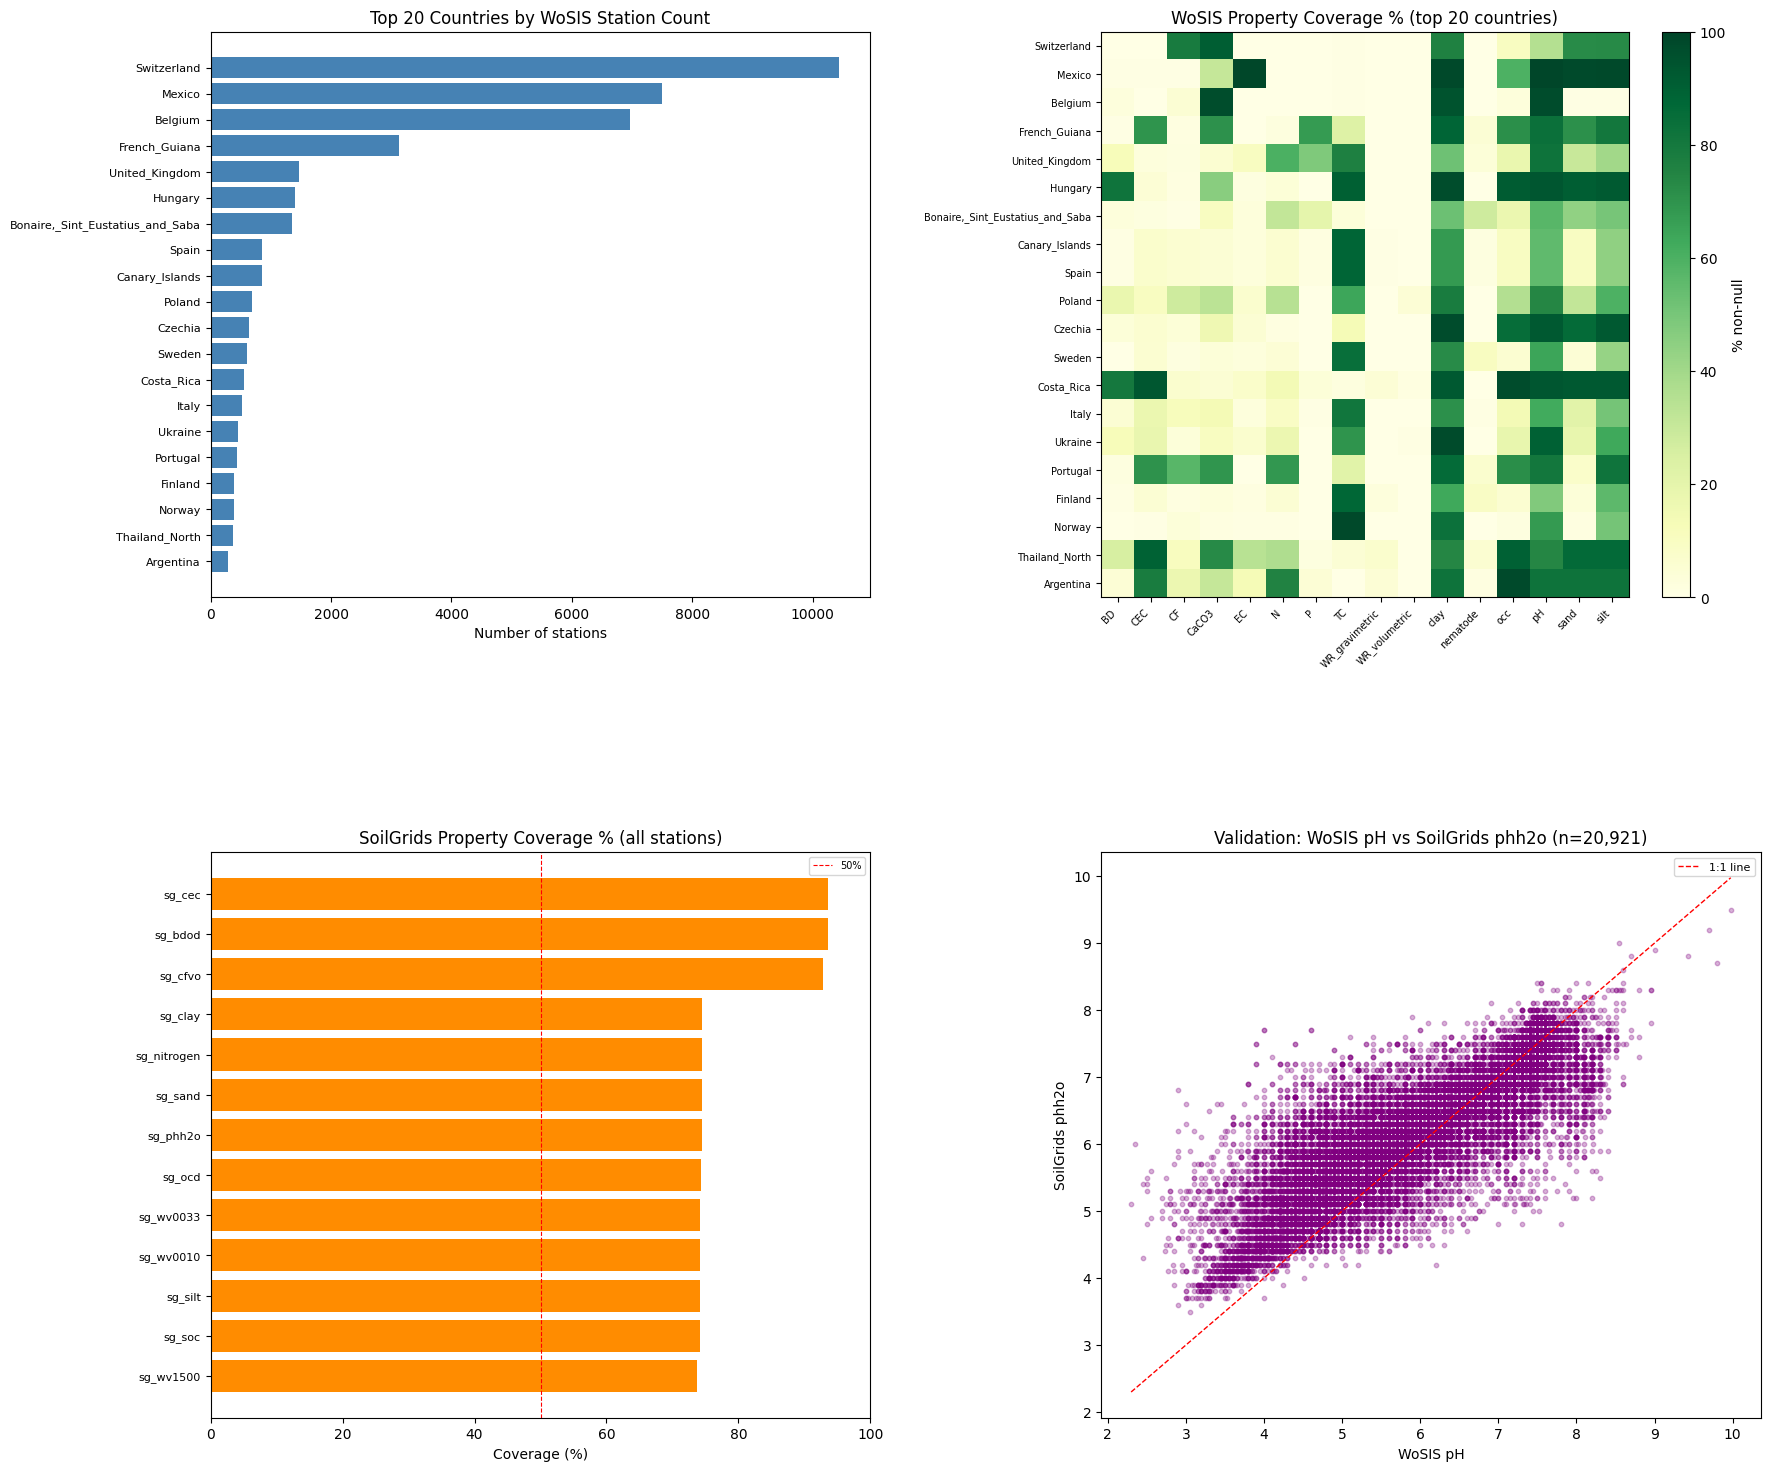

Figure saved: /home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/reports/nb08_consolidation_overview.png


In [7]:
fig = plt.figure(figsize=(20, 18))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ---- Plot 1: Stations per country (top 20) --------------------------------
ax1 = fig.add_subplot(gs[0, 0])
top20 = inv_df.nlargest(20, "n_stations")[["country","n_stations"]].sort_values("n_stations", ascending=True)
ax1.barh(top20["country"], top20["n_stations"], color="steelblue")
ax1.set_xlabel("Number of stations")
ax1.set_title("Top 20 Countries by WoSIS Station Count")
ax1.tick_params(axis='y', labelsize=8)

# ---- Plot 2: WoSIS property coverage heatmap (top 20 countries) ----------
ax2 = fig.add_subplot(gs[0, 1])
top20_names = inv_df.nlargest(20, "n_stations")["country"].tolist()
heat_data = []
for ctry in top20_names:
    sub = merged[merged["country"] == ctry]
    if len(sub) == 0:
        row_vals = [0.0] * len(prop_cols)
    else:
        row_vals = [sub[p].notna().sum() / len(sub) * 100 if p in sub.columns else 0.0
                    for p in prop_cols]
    heat_data.append(row_vals)
import numpy as _np
heat_arr = _np.array(heat_data)
im = ax2.imshow(heat_arr, aspect='auto', cmap='YlGn', vmin=0, vmax=100)
ax2.set_xticks(range(len(prop_cols)))
ax2.set_xticklabels(prop_cols, rotation=45, ha='right', fontsize=7)
ax2.set_yticks(range(len(top20_names)))
ax2.set_yticklabels(top20_names, fontsize=7)
ax2.set_title("WoSIS Property Coverage % (top 20 countries)")
plt.colorbar(im, ax=ax2, label="% non-null")

# ---- Plot 3: SoilGrids property coverage % overall -----------------------
ax3 = fig.add_subplot(gs[1, 0])
if len(sg_cols) > 0 and len(sg_df) > 0:
    sg_cov = [(col, sg_df[col].notna().sum() / len(sg_df) * 100) for col in sg_cols]
    sg_cov_df = pd.DataFrame(sg_cov, columns=["prop","pct"]).sort_values("pct", ascending=True)
    ax3.barh(sg_cov_df["prop"], sg_cov_df["pct"], color="darkorange")
    ax3.set_xlabel("Coverage (%)")
    ax3.set_xlim(0, 100)
    ax3.axvline(50, color='red', linestyle='--', linewidth=0.8, label='50%')
    ax3.legend(fontsize=7)
ax3.set_title("SoilGrids Property Coverage % (all stations)")
ax3.tick_params(axis='y', labelsize=8)

# ---- Plot 4: Validation scatter -- WoSIS pH vs SoilGrids phh2o ----------
ax4 = fig.add_subplot(gs[1, 1])
ph_col = next((c for c in merged.columns if c.lower() in ['ph','phh2o','ph_water']), None)
sg_ph_col = 'sg_phh2o' if 'sg_phh2o' in merged.columns else None
if ph_col and sg_ph_col:
    valid = merged[[ph_col, sg_ph_col]].dropna()
    ax4.scatter(valid[ph_col], valid[sg_ph_col], alpha=0.3, s=10, color='purple')
    mn = min(valid[ph_col].min(), valid[sg_ph_col].min())
    mx = max(valid[ph_col].max(), valid[sg_ph_col].max())
    ax4.plot([mn, mx], [mn, mx], 'r--', linewidth=1, label='1:1 line')
    ax4.set_xlabel(f'WoSIS {ph_col}')
    ax4.set_ylabel('SoilGrids phh2o')
    ax4.set_title(f'Validation: WoSIS {ph_col} vs SoilGrids phh2o (n={len(valid):,})')
    ax4.legend(fontsize=8)
else:
    ax4.text(0.5, 0.5, 'pH data not available for scatter\n(check property names)',
             ha='center', va='center', transform=ax4.transAxes, fontsize=10)
    ax4.set_title('Validation: WoSIS pH vs SoilGrids phh2o')

fig_path = os.path.join(OUTPUT_DIR, "nb08_consolidation_overview.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {fig_path}")

## Save Outputs & Summary

In [8]:
# Save merged dataset
out_path = "/home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/combined_soilhive_dataset.parquet"
merged.to_parquet(out_path, index=False)
print(f"Merged dataset saved: {out_path}")
print(f"File size: {os.path.getsize(out_path)/1e6:.2f} MB")

# Also save inventory
inv_out = os.path.join(OUTPUT_DIR, "nb08_inventory.csv")
inv_df[[col for col in inv_df.columns if col not in ['wosis_props','sg_props']]].to_csv(inv_out, index=False)
print(f"Inventory saved: {inv_out}")

print()
print("=" * 70)
print("SYNTHESE NB08 - Consolidation SoilHive")
print("=" * 70)
print(f"Countries processed    : {len(countries)}")
print(f"Total WoSIS stations   : {wosis_wide.shape[0]:,}")
print(f"Total WoSIS rows       : {len(wosis_df):,}")
print(f"SoilGrids props        : {len(sg_cols)}")
print(f"Merged dataset shape   : {merged.shape}")
print(f"Stations empty (WoSIS) : {empty} ({empty/len(merged)*100:.1f}%)")
n_no_sg = merged["sg_match_dist_km"].isna().sum()
print(f"Stations no SG match   : {n_no_sg} ({n_no_sg/len(merged)*100:.1f}%)")
print(f"Issues logged          : {len(issues)}")
print(f"Output saved to        : combined_soilhive_dataset.parquet")

Merged dataset saved: /home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/combined_soilhive_dataset.parquet
File size: 1.77 MB
Inventory saved: /home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/reports/nb08_inventory.csv

SYNTHESE NB08 - Consolidation SoilHive
Countries processed    : 62
Total WoSIS stations   : 42,298
Total WoSIS rows       : 909,214
SoilGrids props        : 13
Merged dataset shape   : (42298, 33)
Stations empty (WoSIS) : 0 (0.0%)
Stations no SG match   : 178 (0.4%)
Issues logged          : 7
Output saved to        : combined_soilhive_dataset.parquet
